# Advanced Inference: Pathfinder, Elliptical Slice Sampling, and Laplace

tengri ships eight inference strategies, all optimizing the same loss function
$H(\xi \mid d) = \frac{1}{2}\chi^2 + \frac{1}{2}\xi^\top\xi$. This notebook
introduces three new methods and compares them against the established baselines.

| Method | Type | Exact? | Best for |
|--------|------|--------|----------|
| **Laplace** | Gaussian at MAP | No | Instant error bars, evidence |
| **Pathfinder** | L-BFGS path VI | No | Fast approximate, NUTS init |
| **Elliptical Slice** | MCMC | Yes | Gaussian-prior latent models |
| geoVI | Variational | No | Default (any D) |
| NUTS | MCMC | Yes | Gold standard (D < 20) |
| Ray Tracing | MCMC | Yes | Exact (any D) |

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Parameters,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

## 1. Setup: Parametric Model (D = 7)

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, filters=filters)

key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(0.3)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)

mock = model.mock(true_params, snr=20.0, key=key)
fitter = Fitter(model, mock.flux_obs, mock.noise)
print(f"Model: D = {spec.n_free}, N_data = {len(mock.flux_obs)}")

W0405 02:49:35.324769 36268366 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81722/3663150543.py:19: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, filters=filters)


Model: D = 8, N_data = 5


In [3]:
timings = {}
t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=500, verbose=False)
timings["MAP"] = time.perf_counter() - t0
print(f"MAP: {timings['MAP']:.1f}s")

MAP: 0.4s


## 2. Laplace Approximation

Hessian $H$ of the loss at MAP, inverted to give $\mathcal{N}(\hat\theta, H^{-1})$.
Eigenvalue spectrum shows which params are constrained vs degenerate.

In [4]:
t0 = time.perf_counter()
result_laplace = fitter.run(
    "laplace",
    init_from=result_map,
    n_samples=5000,
    verbose=False,
)
timings["Laplace"] = time.perf_counter() - t0
print(f"Laplace: {timings['Laplace']:.1f}s")
print(f"  Log-evidence: {result_laplace.diagnostics.get('log_evidence', 'N/A')}")
print(f"  Condition number: {result_laplace.diagnostics.get('condition_number', 'N/A'):.1e}")

Laplace: 8.0s
  Log-evidence: 11.843237696439491
  Condition number: 9.5e+09


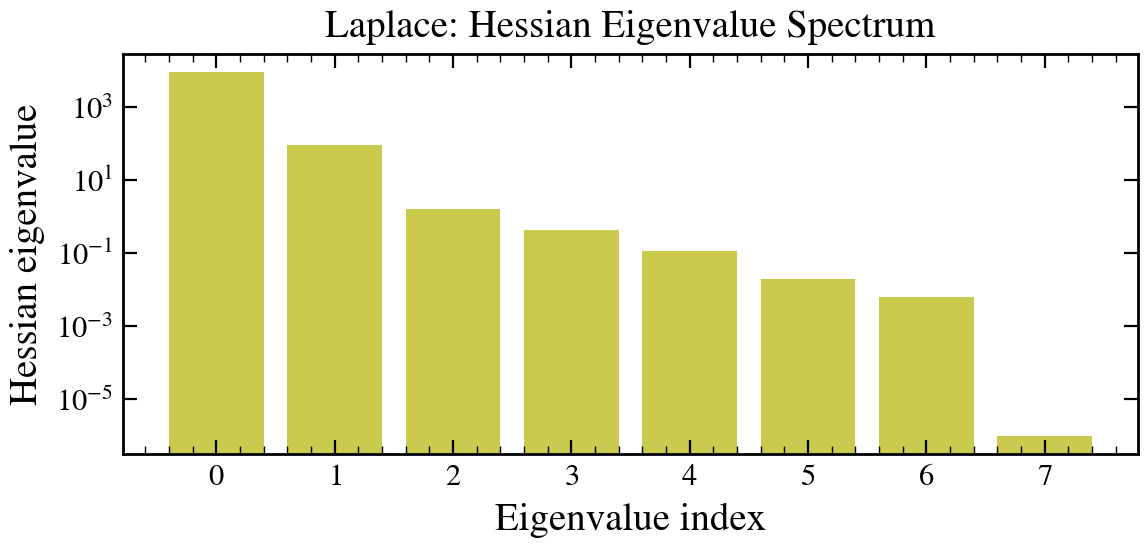

In [5]:
if "eigenvalues" in result_laplace.diagnostics:
    eigs = np.array(result_laplace.diagnostics["eigenvalues"])
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(range(len(eigs)), np.sort(eigs)[::-1], color=COLORS["laplace"], alpha=0.8)
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Hessian eigenvalue")
    ax.set_title("Laplace: Hessian Eigenvalue Spectrum")
    ax.set_yscale("log")
    fig.tight_layout()
    plt.show()

## 3. Pathfinder

In [6]:
t0 = time.perf_counter()
result_pathfinder = fitter.run(
    "pathfinder",
    n_samples=5000,
    maxiter=30,
    verbose=False,
)
timings["Pathfinder"] = time.perf_counter() - t0
print(f"Pathfinder: {timings['Pathfinder']:.1f}s")

W0405 02:49:49.426221 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Pathfinder: 10.8s


## 4. Elliptical Slice Sampling

In [7]:
t0 = time.perf_counter()
result_ess = fitter.run(
    "mcmc_ess",
    init_from=result_map,
    n_samples=5000,
    n_burnin=500,
    verbose=False,
)
timings["ESS"] = time.perf_counter() - t0
print(f"Elliptical Slice: {timings['ESS']:.1f}s")

Elliptical Slice: 7.0s


## 5. Baselines: geoVI and NUTS

In [8]:
fitter.compile(verbose=False)

t0 = time.perf_counter()
result_geovi = fitter.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=5000,
    verbose=False,
)
timings["geoVI"] = time.perf_counter() - t0

t0 = time.perf_counter()
result_nuts = fitter.run(
    "mcmc_nuts",
    n_warmup=500,
    n_samples=5000,
    init_from=result_map,
    verbose=False,
)
timings["NUTS"] = time.perf_counter() - t0

print(f"geoVI: {timings['geoVI']:.1f}s")
print(f"NUTS:  {timings['NUTS']:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:50:04.457750 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:50:05.919829 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 02:50:18.817654 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:50:32.448254 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 3.6 ± 1.0 (CV=27%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 02:50:42.617113 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


geoVI: 41.8s
NUTS:  85.2s


## 6. Corner Plots

### 6a. Laplace vs NUTS: Does the Gaussian Approximation Hold?

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


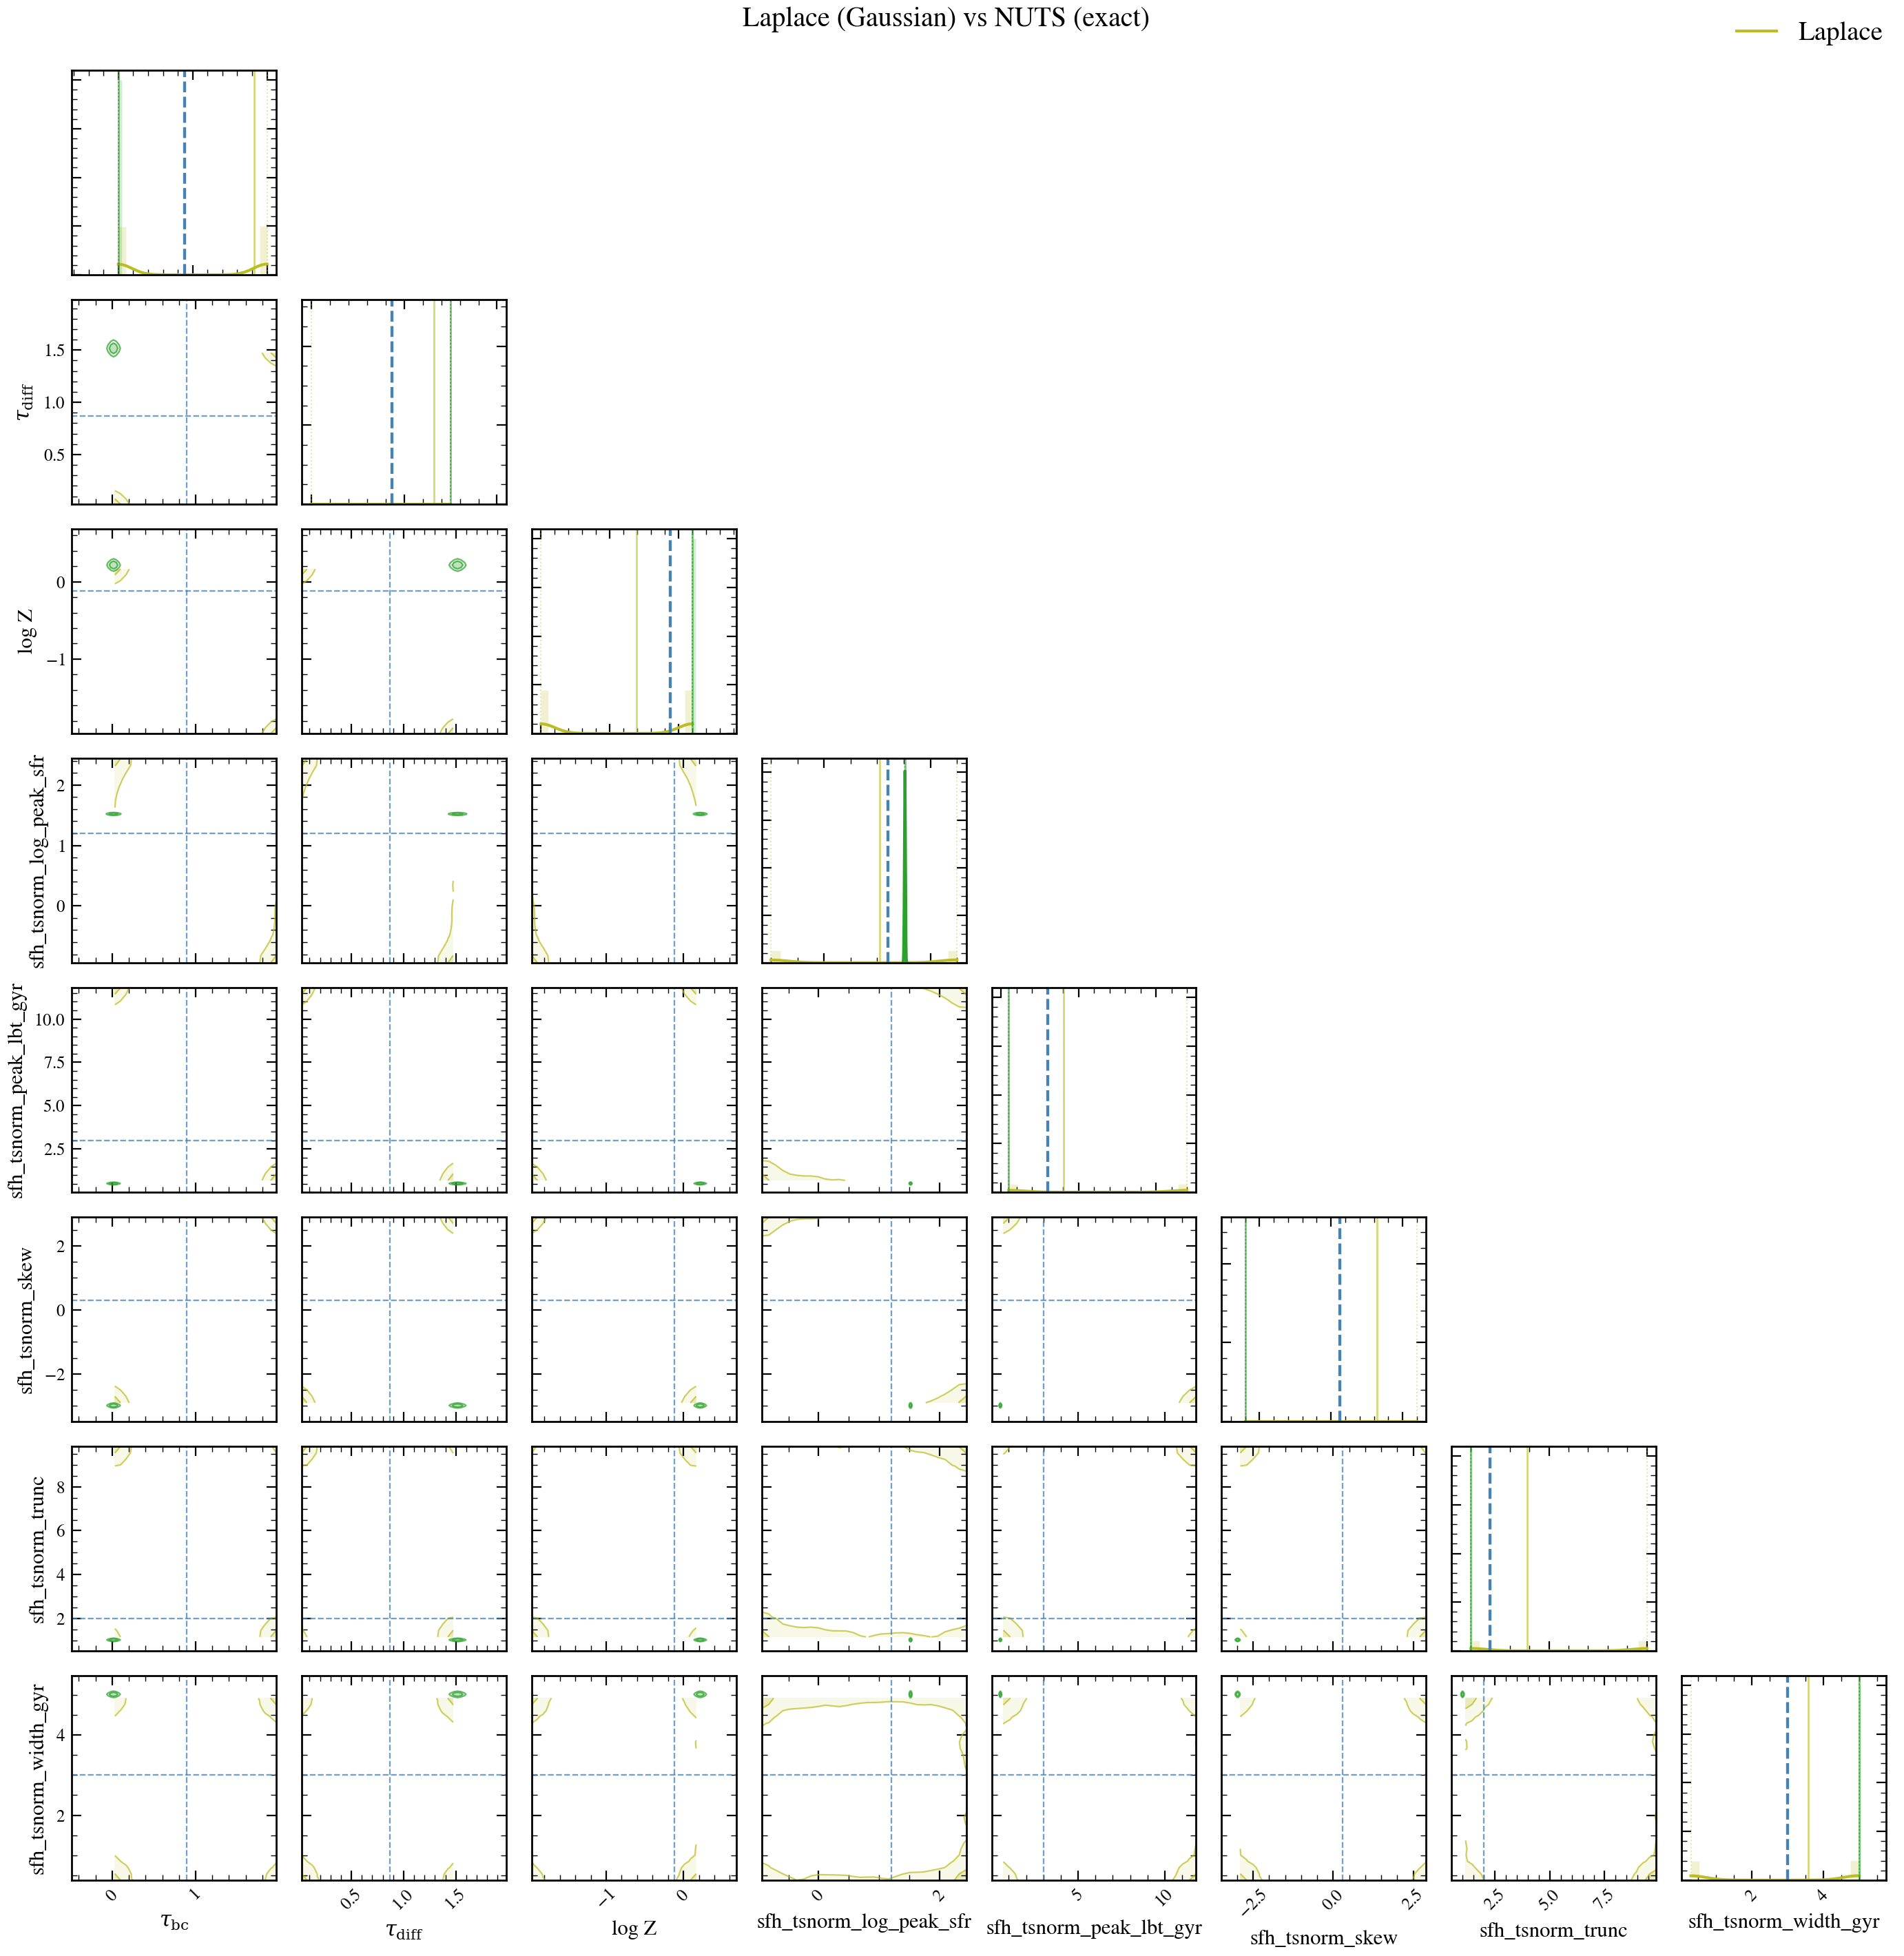

In [9]:
fig = plot_corner_comparison(
    [result_laplace, result_nuts],
    labels=["Laplace", "NUTS"],
    colors=[COLORS["laplace"], COLORS["nuts"]],
    truths=true_params,
)
if fig is not None:
    fig.suptitle("Laplace (Gaussian) vs NUTS (exact)", y=1.02)
    plt.savefig("fig01a_corner_laplace_vs_nuts.png", dpi=150, bbox_inches="tight")
plt.show()

### 6b. Pathfinder vs NUTS

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


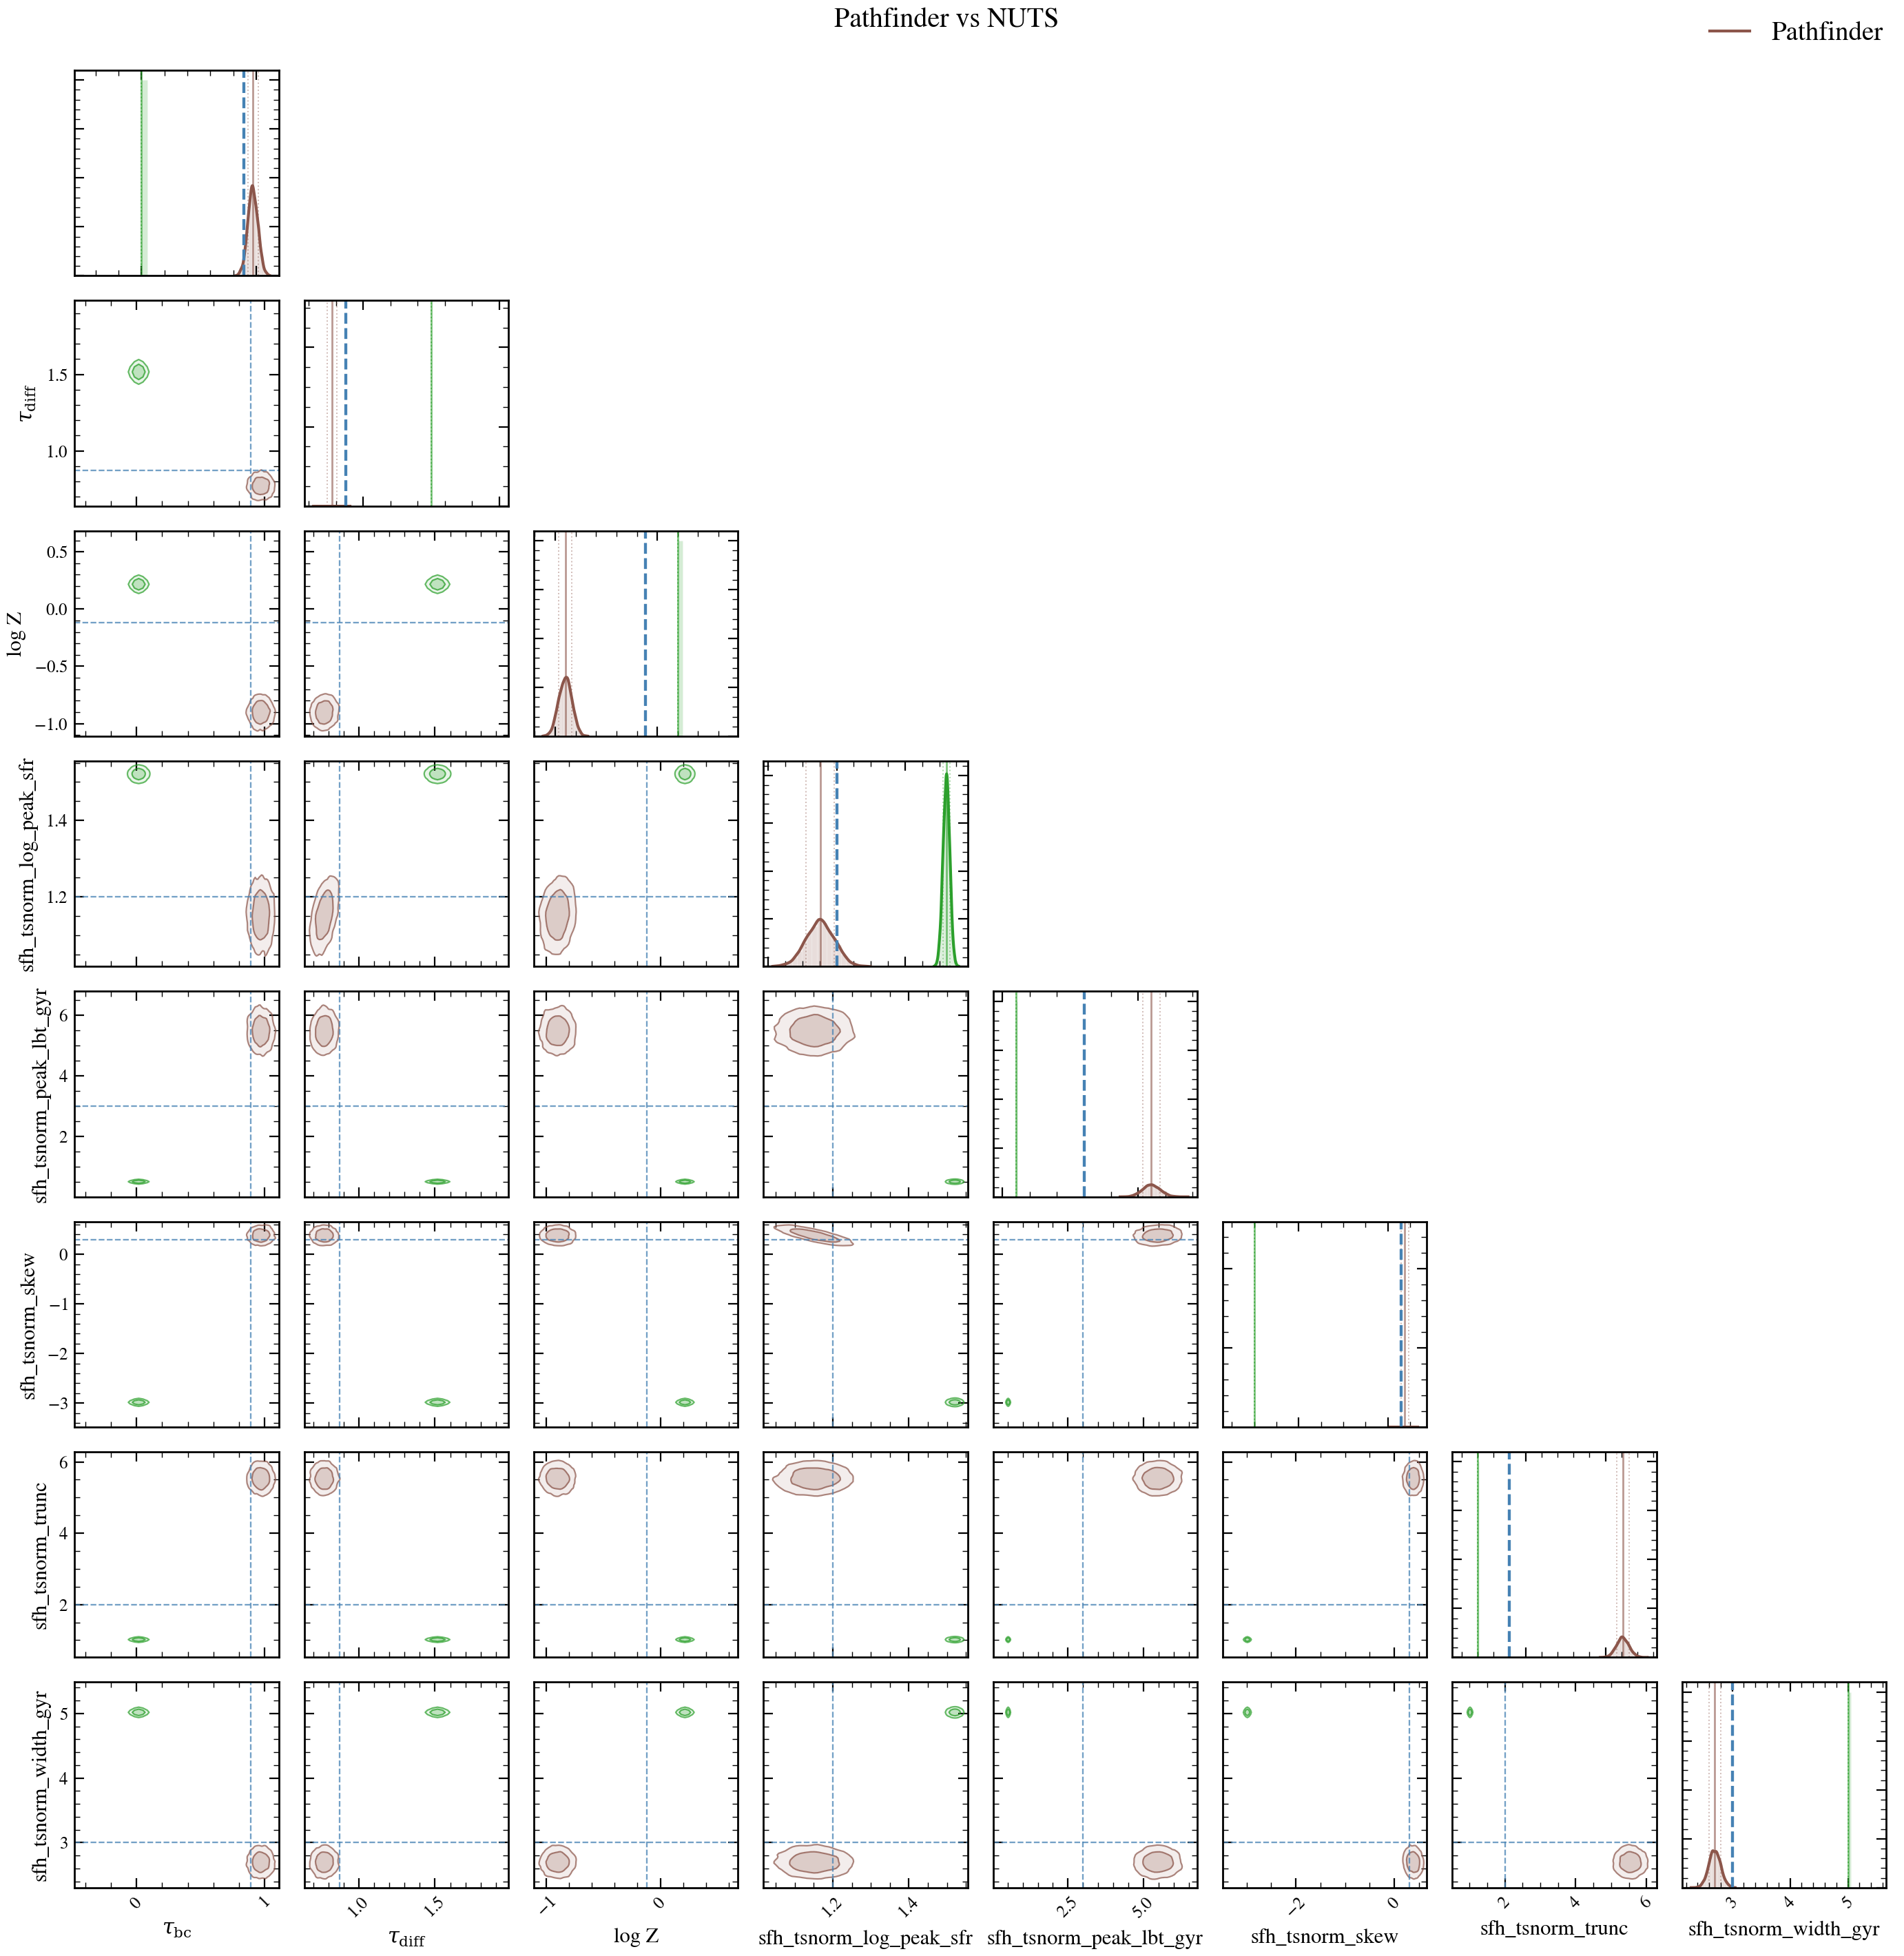

In [10]:
fig = plot_corner_comparison(
    [result_pathfinder, result_nuts],
    labels=["Pathfinder", "NUTS"],
    colors=[COLORS["pathfinder"], COLORS["nuts"]],
    truths=true_params,
)
if fig is not None:
    fig.suptitle("Pathfinder vs NUTS", y=1.02)
    plt.savefig("fig01b_corner_pathfinder_vs_nuts.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. ESS vs NUTS

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


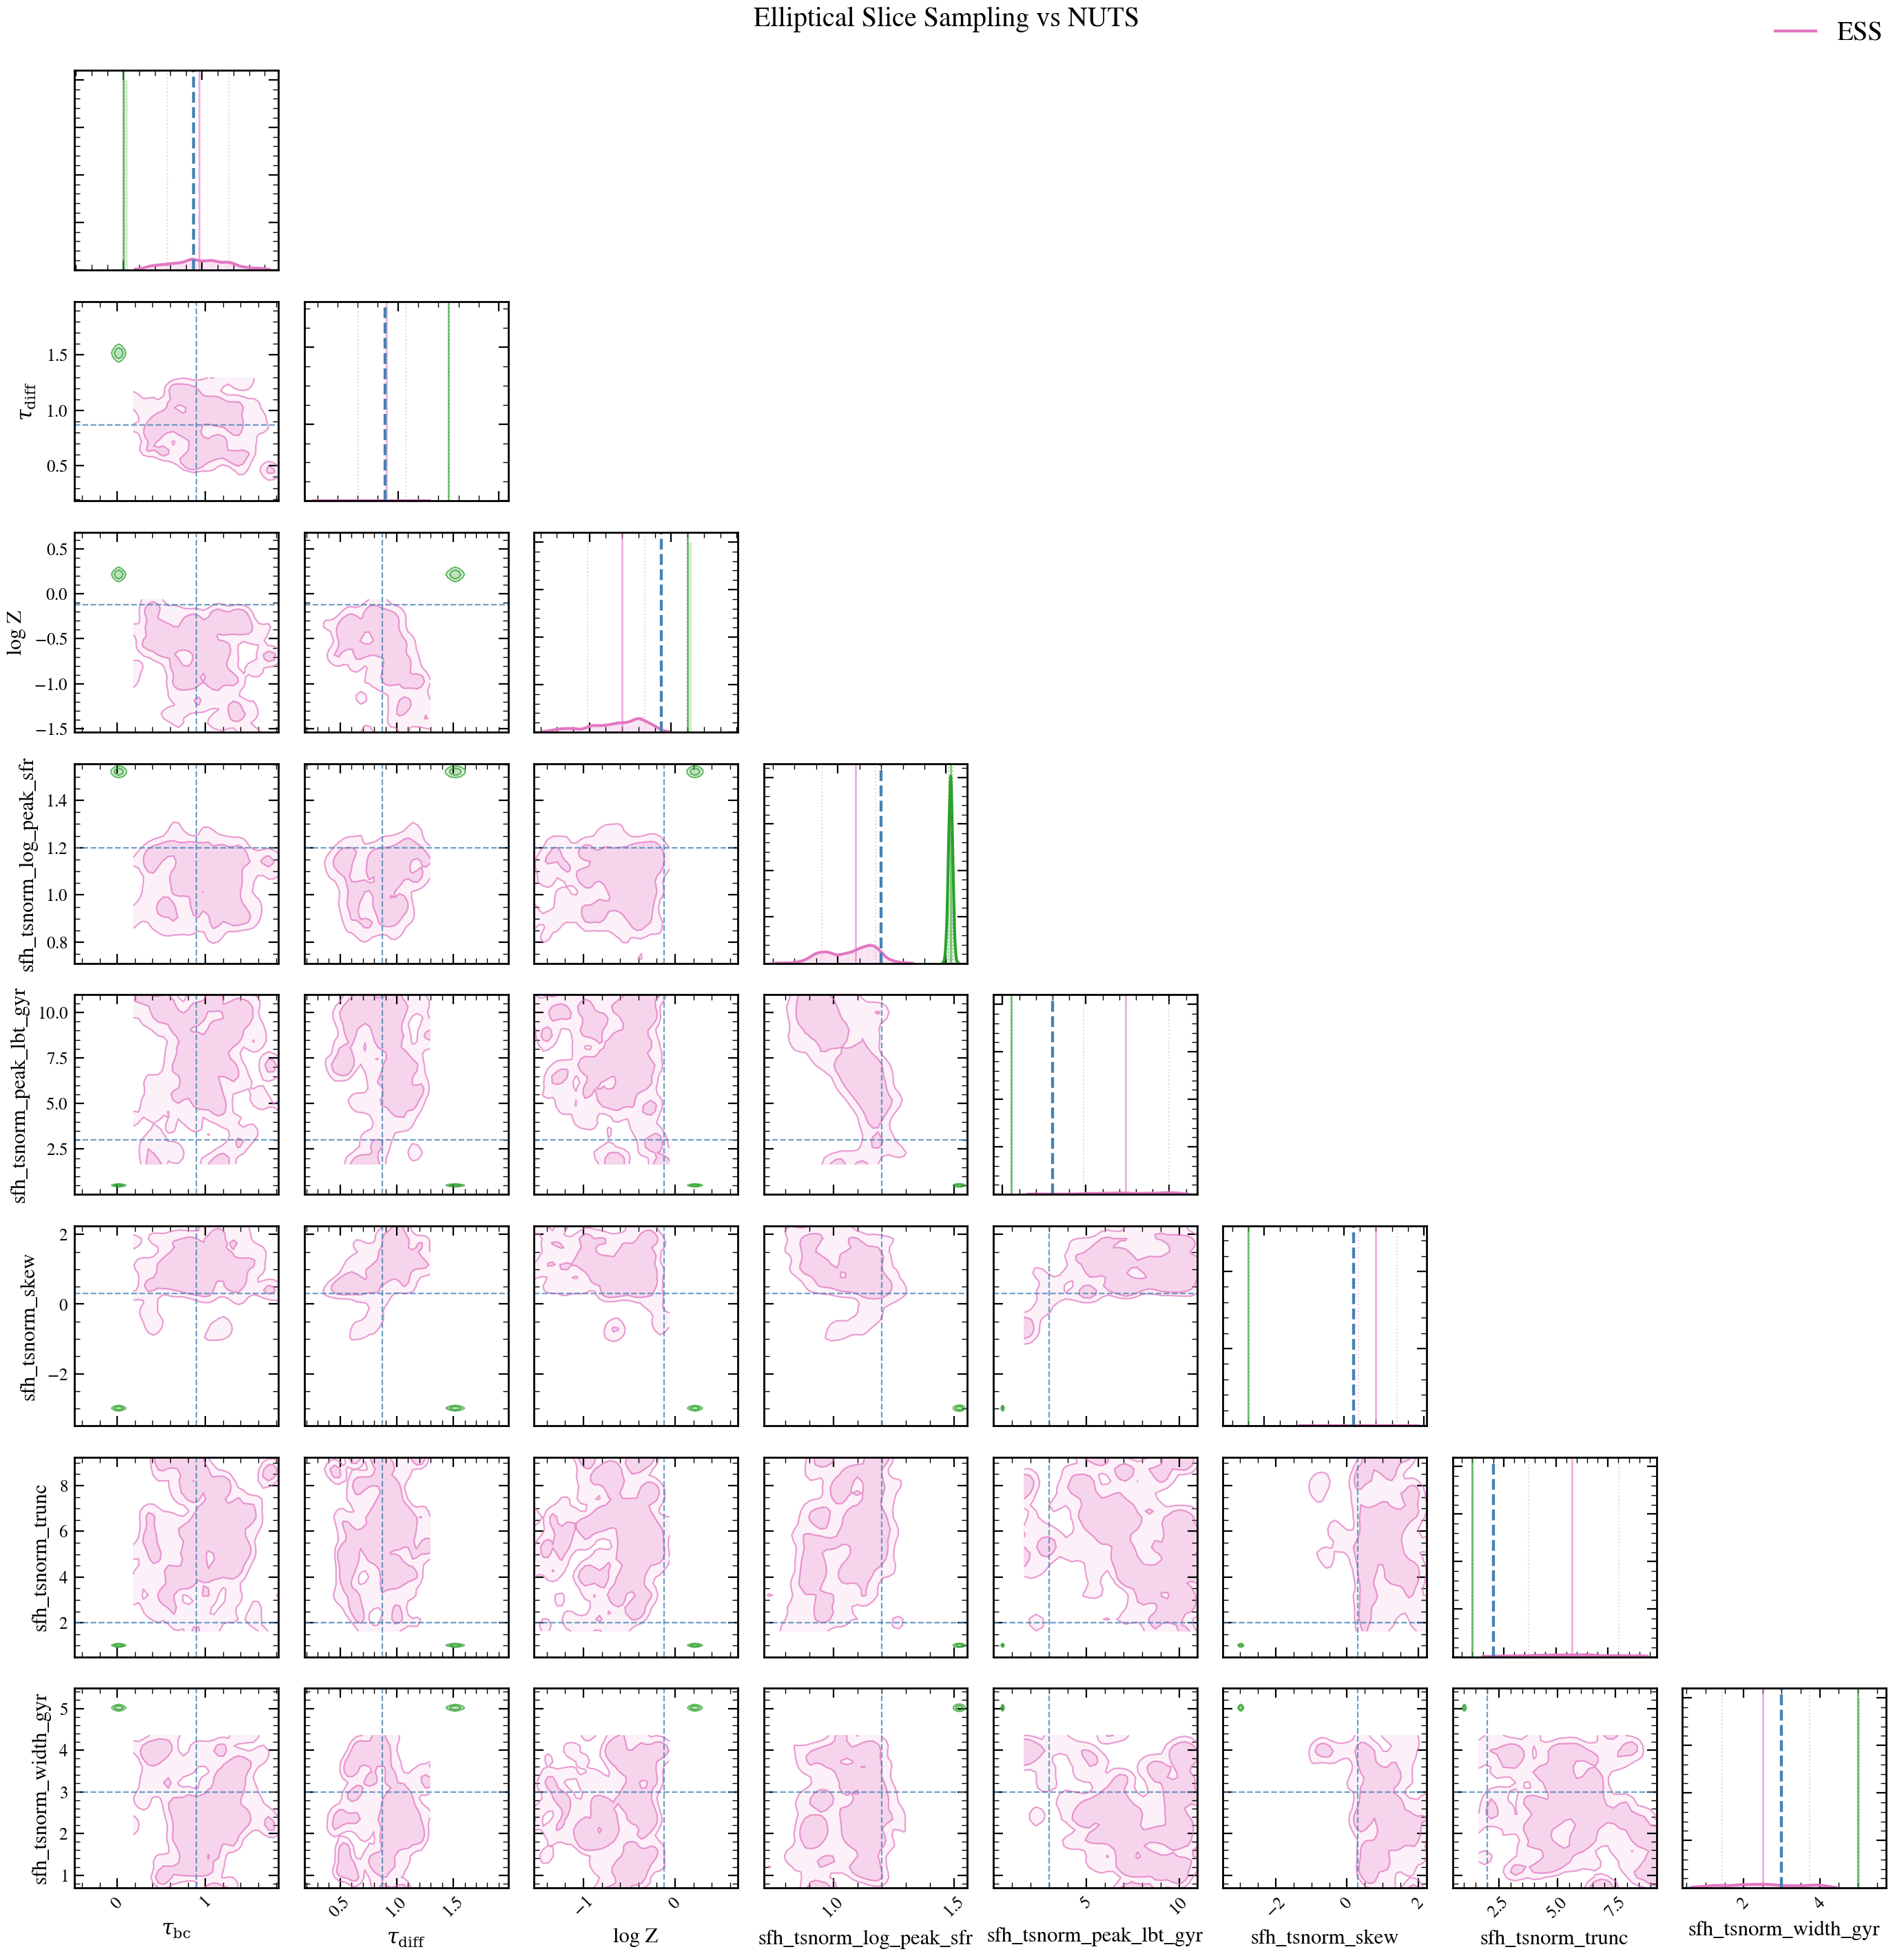

In [11]:
fig = plot_corner_comparison(
    [result_ess, result_nuts],
    labels=["ESS", "NUTS"],
    colors=[COLORS["ess"], COLORS["nuts"]],
    truths=true_params,
)
if fig is not None:
    fig.suptitle("Elliptical Slice Sampling vs NUTS", y=1.02)
    plt.savefig("fig01c_corner_ess_vs_nuts.png", dpi=150, bbox_inches="tight")
plt.show()

### 6d. All Five Methods

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

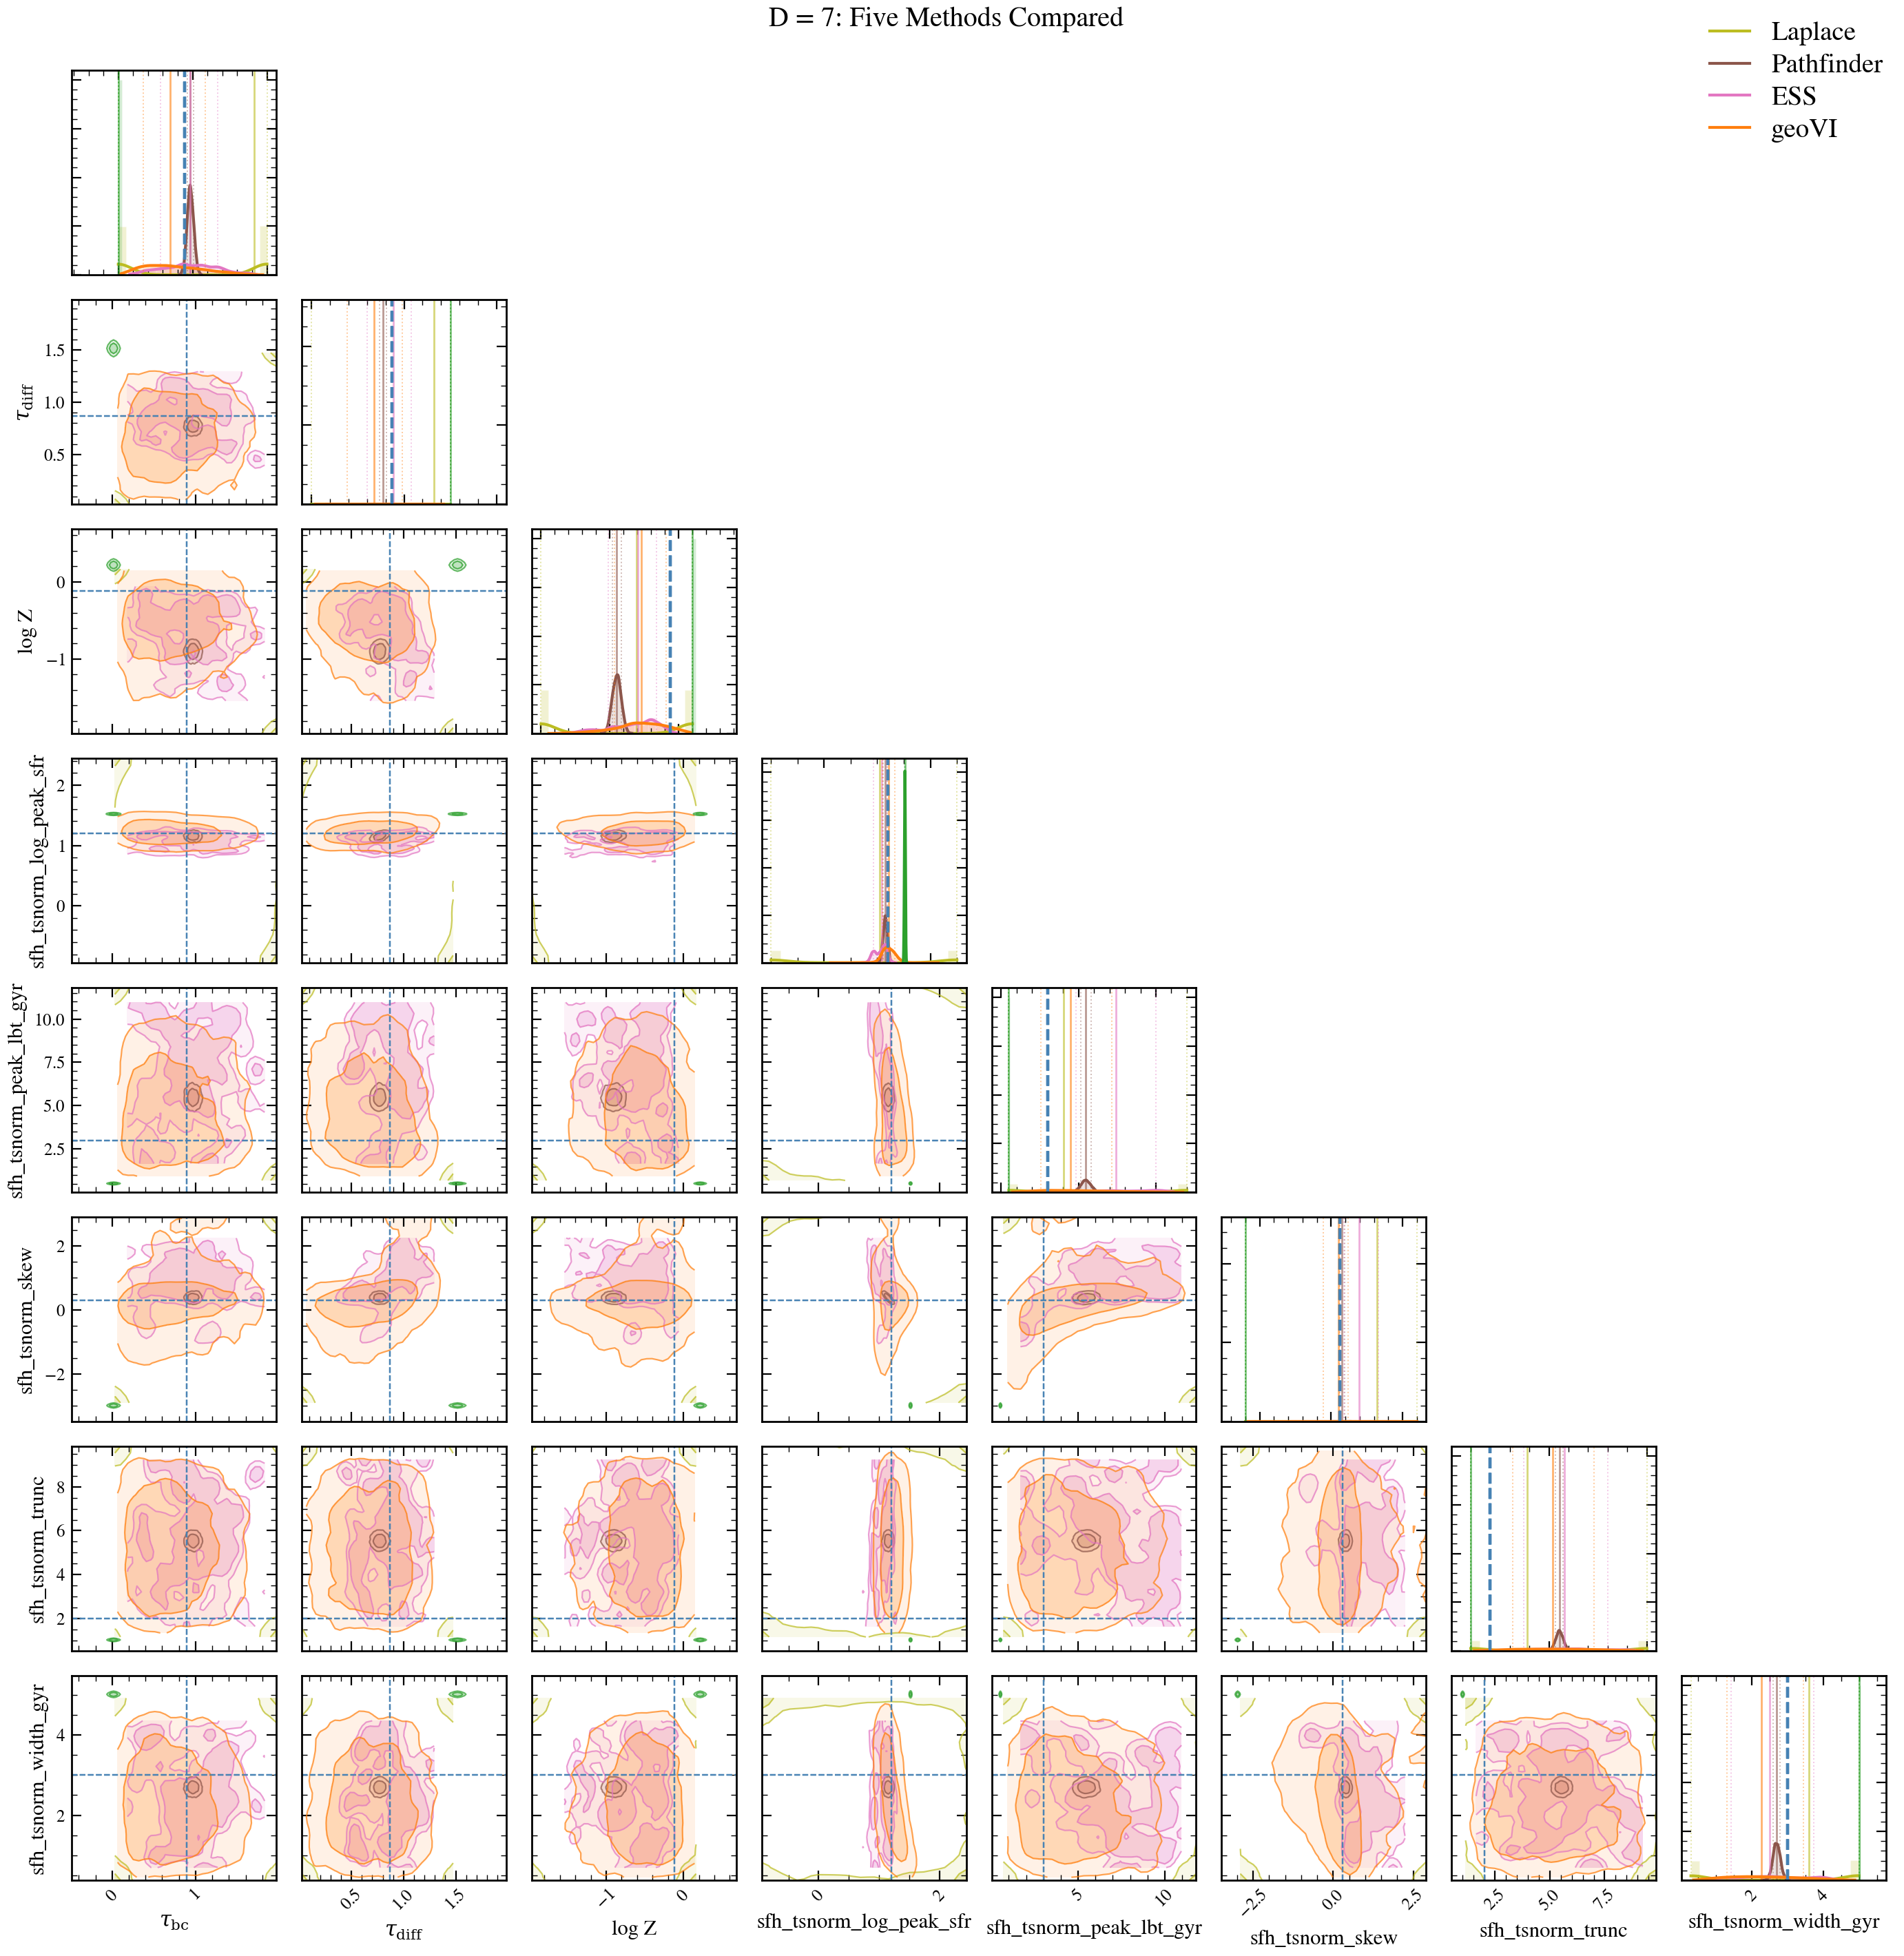

In [12]:
fig = plot_corner_comparison(
    [result_laplace, result_pathfinder, result_ess, result_geovi, result_nuts],
    labels=["Laplace", "Pathfinder", "ESS", "geoVI", "NUTS"],
    colors=[
        COLORS["laplace"],
        COLORS["pathfinder"],
        COLORS["ess"],
        COLORS["geovi"],
        COLORS["nuts"],
    ],
    truths=true_params,
)
if fig is not None:
    fig.suptitle("D = 7: Five Methods Compared", y=1.02)
    plt.savefig("fig01d_corner_all_methods.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 1D Marginal Posteriors

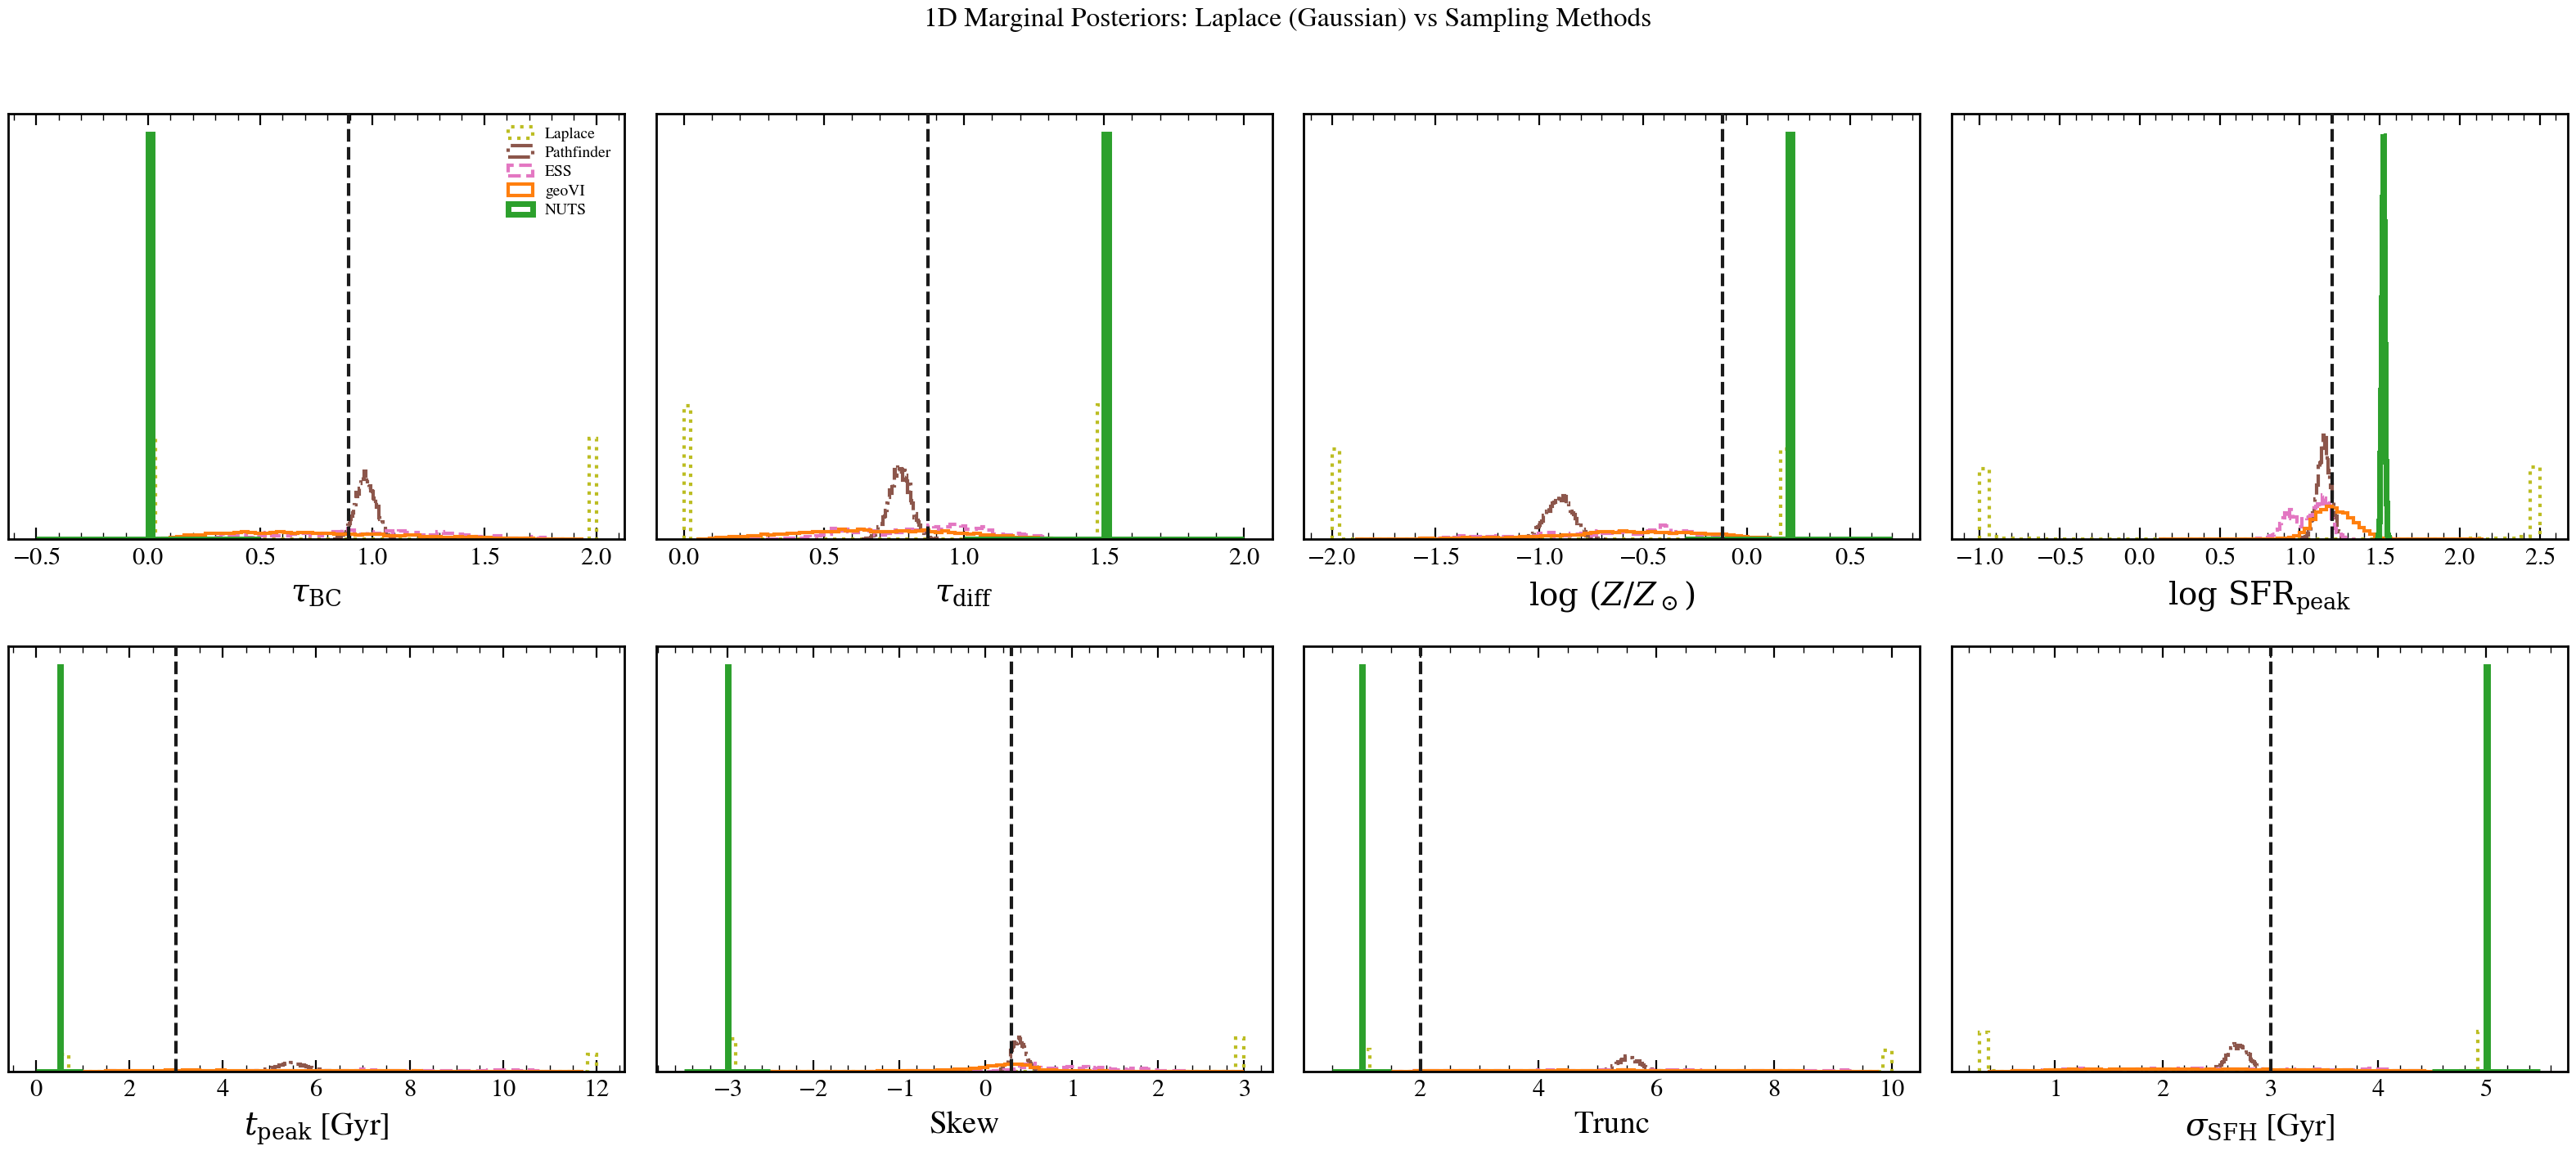

In [13]:
phys_params = [p for p in spec.free_params if "xi" not in p]

_PARAM_LABELS = {
    "sfh_tsnorm_log_peak_sfr": r"$\log\,\mathrm{SFR_{peak}}$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$ [Gyr]",
    "sfh_tsnorm_width_gyr": r"$\sigma_{\rm SFH}$ [Gyr]",
    "sfh_tsnorm_skew": "Skew",
    "sfh_tsnorm_trunc": "Trunc",
    "met_logzsol": r"$\log\,(Z/Z_\odot)$",
    "dust_tau_bc": r"$\tau_{\rm BC}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
}

all_results = {
    "Laplace": (result_laplace, COLORS["laplace"], ":"),
    "Pathfinder": (result_pathfinder, COLORS["pathfinder"], "-."),
    "ESS": (result_ess, COLORS["ess"], "--"),
    "geoVI": (result_geovi, COLORS["geovi"], "-"),
    "NUTS": (result_nuts, COLORS["nuts"], "-"),
}

n_params = len(phys_params)
n_cols = min(4, n_params)
n_rows = (n_params + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes_flat = np.atleast_1d(axes).ravel()

for idx, pname in enumerate(phys_params):
    ax = axes_flat[idx]
    truth_val = float(true_params.get(pname, np.nan))

    for method_name, (result, color, ls) in all_results.items():
        if result.samples is not None and pname in result.samples:
            samples = np.array(result.samples[pname]).ravel()
            lw = 2.5 if method_name == "NUTS" else 1.5
            ax.hist(
                samples,
                bins=60,
                density=True,
                histtype="step",
                color=color,
                ls=ls,
                lw=lw,
                label=method_name,
            )
            if method_name == "NUTS":
                ax.hist(
                    samples,
                    bins=60,
                    density=True,
                    histtype="stepfilled",
                    color=color,
                    alpha=0.12,
                )

    if np.isfinite(truth_val):
        ax.axvline(truth_val, color=COLORS["truth"], lw=1.5, ls="--", zorder=10)

    ax.set_xlabel(_PARAM_LABELS.get(pname, pname))
    ax.set_yticks([])
    if idx == 0:
        ax.legend(fontsize=7, loc="upper right")

for idx in range(n_params, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    "1D Marginal Posteriors: Laplace (Gaussian) vs Sampling Methods",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
plt.savefig("fig05_marginal_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Posterior Summary Table

In [14]:
print(f"  {'Parameter':<30s}", end="")
for name in ["Laplace", "Pathfinder", "ESS", "geoVI", "NUTS"]:
    print(f"  {name:>22s}", end="")
print(f"  {'Truth':>8s}")
print("  " + "-" * 148)

for pname in phys_params:
    label = _PARAM_LABELS.get(pname, pname)
    print(f"  {label:<30s}", end="")
    for method_name in ["Laplace", "Pathfinder", "ESS", "geoVI", "NUTS"]:
        result = all_results[method_name][0]
        if result.samples is not None and pname in result.samples:
            s = np.array(result.samples[pname]).ravel()
            med = np.median(s)
            lo, hi = np.percentile(s, [16, 84])
            print(f"  {med:>7.2f} [{lo:>6.2f}, {hi:>6.2f}]", end="")
        else:
            print(f"  {'---':>22s}", end="")
    truth_val = float(true_params.get(pname, np.nan))
    print(f"  {truth_val:>8.2f}")

  Parameter                                      Laplace              Pathfinder                     ESS                   geoVI                    NUTS     Truth
  ----------------------------------------------------------------------------------------------------------------------------------------------------
  $\tau_{\rm BC}$                    1.83 [  0.00,   2.00]     0.97 [  0.93,   1.01]     0.96 [  0.57,   1.34]     0.69 [  0.34,   1.17]     0.00 [  0.00,   0.00]      0.89
  $\tau_{\rm diff}$                  1.32 [  0.00,   1.50]     0.77 [  0.73,   0.81]     0.89 [  0.60,   1.08]     0.68 [  0.39,   0.98]     1.50 [  1.50,   1.50]      0.87
  $\log\,(Z/Z_\odot)$               -0.61 [ -2.00,   0.20]    -0.90 [ -0.97,  -0.84]    -0.60 [ -1.02,  -0.32]    -0.54 [ -0.93,  -0.19]     0.20 [  0.20,   0.20]     -0.12
  $\log\,\mathrm{SFR_{peak}}$        1.05 [ -1.00,   2.50]     1.15 [  1.11,   1.19]     1.08 [  0.93,   1.18]     1.21 [  1.10,   1.34]     1.52 [  1.51,   1.53]     

In [15]:
print("\n  Relative 68% CI width (NUTS = 1.0):")
print(f"  {'Parameter':<30s}", end="")
for name in ["Laplace", "Pathfinder", "ESS", "geoVI"]:
    print(f"  {name:>12s}", end="")
print()
print("  " + "-" * 82)

for pname in phys_params:
    label = _PARAM_LABELS.get(pname, pname)
    nuts_s = np.array(result_nuts.samples[pname]).ravel()
    nuts_width = np.percentile(nuts_s, 84) - np.percentile(nuts_s, 16)
    if nuts_width < 1e-10:
        continue
    print(f"  {label:<30s}", end="")
    for method_name in ["Laplace", "Pathfinder", "ESS", "geoVI"]:
        result = all_results[method_name][0]
        if result.samples is not None and pname in result.samples:
            s = np.array(result.samples[pname]).ravel()
            width = np.percentile(s, 84) - np.percentile(s, 16)
            print(f"  {width / nuts_width:>12.2f}", end="")
        else:
            print(f"  {'---':>12s}", end="")
    print()


  Relative 68% CI width (NUTS = 1.0):
  Parameter                            Laplace    Pathfinder           ESS         geoVI
  ----------------------------------------------------------------------------------
  $\log\,\mathrm{SFR_{peak}}$           175.79          4.17         12.56         11.92


## 9. Timing Comparison

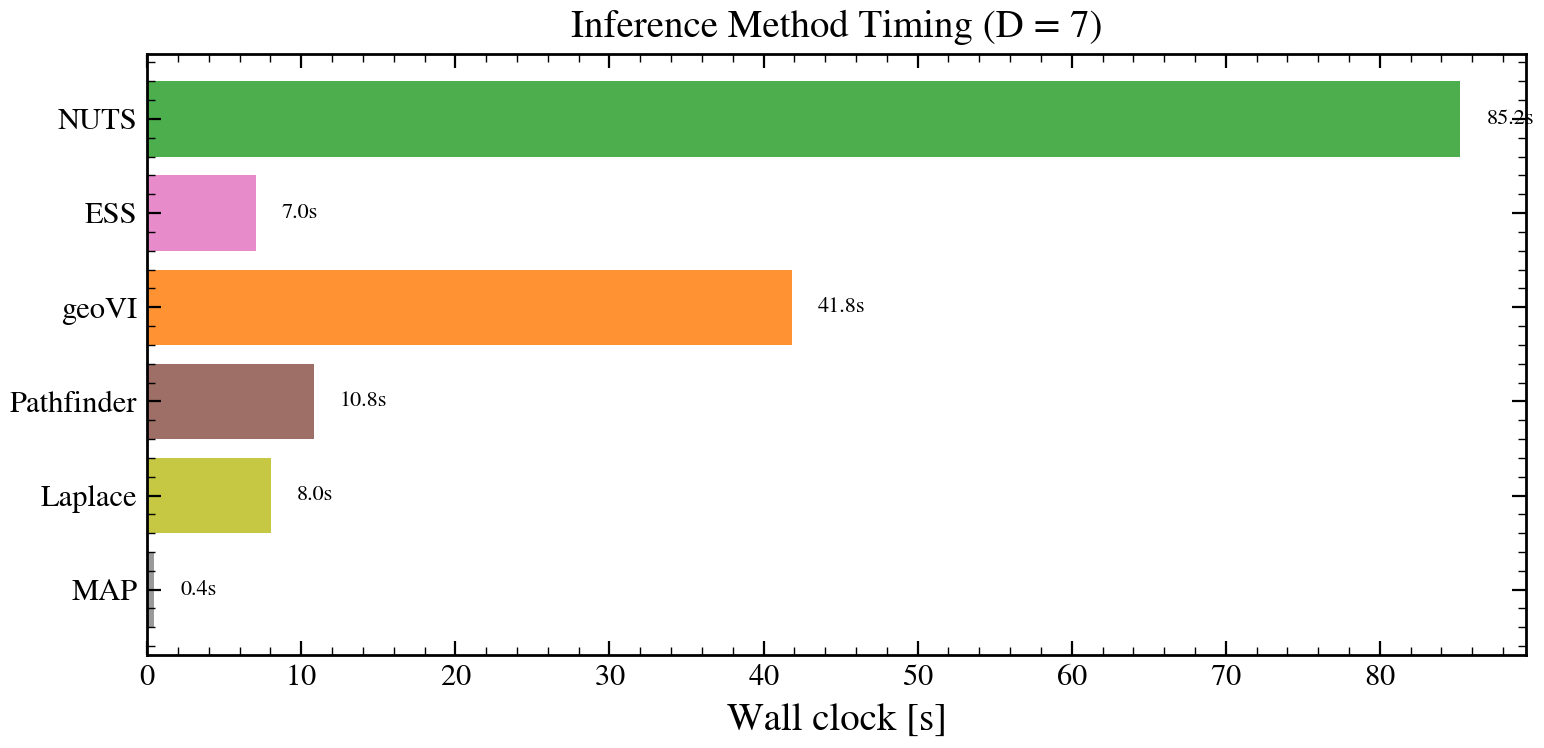

In [16]:
method_names = ["MAP", "Laplace", "Pathfinder", "geoVI", "ESS", "NUTS"]
method_colors = [
    COLORS["map"],
    COLORS["laplace"],
    COLORS["pathfinder"],
    COLORS["geovi"],
    COLORS["ess"],
    COLORS["nuts"],
]
times = [timings[m] for m in method_names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(method_names)), times, color=method_colors, alpha=0.85)
ax.set_yticks(range(len(method_names)))
ax.set_yticklabels(method_names)
ax.set_xlabel("Wall clock [s]")
ax.set_title("Inference Method Timing (D = 7)")
for bar, t in zip(bars, times):
    ax.text(
        bar.get_width() + max(times) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{t:.1f}s",
        va="center",
        fontsize=8,
    )
fig.tight_layout()
plt.savefig("fig02_timing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Convergence Diagnostics

In [17]:
ct = convergence_table(
    {
        "Laplace": result_laplace,
        "Pathfinder": result_pathfinder,
        "ESS": result_ess,
        "geoVI": result_geovi,
        "NUTS": result_nuts,
    }
)

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
Laplace             3939     4173      1.3        —        —         OK
Pathfinder          4200     4333      1.2        —        —         OK
ESS                    2        3   2211.2        —        —       WARN
geoVI               3804     4153      1.3        —        —         OK
NUTS                1513     1513      3.3        —       43       WARN

Warnings:
  [ESS] Low ESS: 8/8 params below 100 (min ESS = 2 for dust_tau_bc)
  [ESS] Median ESS = 3 < 400 target — consider more samples
  [ESS] Chain too short for 8 params (need N > 5τ; worst: sfh_tsnorm_width_gyr with τ=2211.2)
  [NUTS] WARNING: 43/5000 divergent transitions (0.9%) — posterior may be unreliable


## 11. SFH Recovery

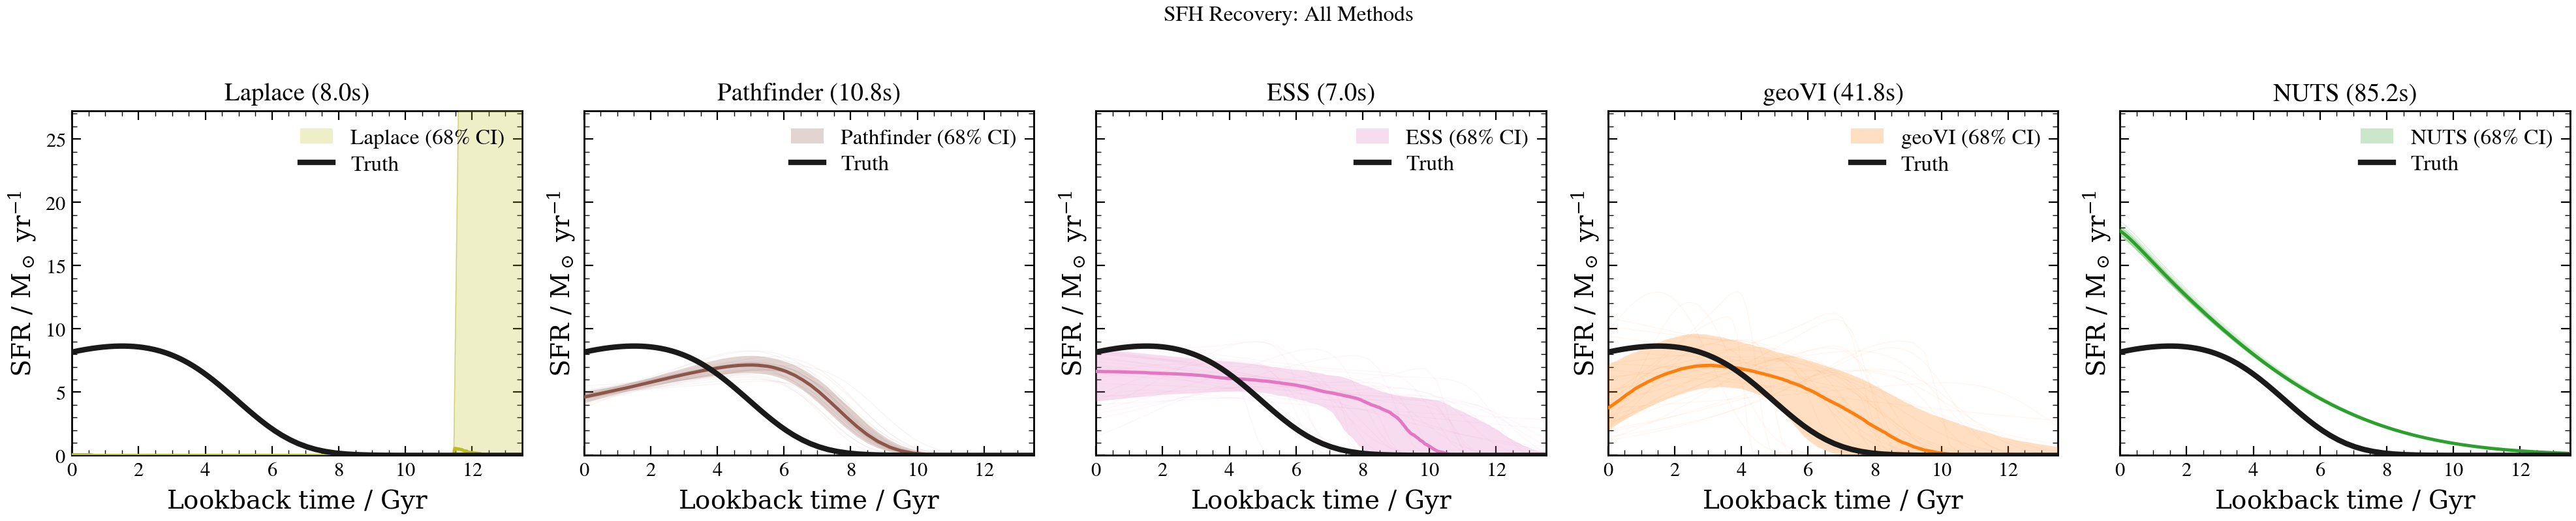

In [18]:
sfh_results = {
    "Laplace": (result_laplace, COLORS["laplace"]),
    "Pathfinder": (result_pathfinder, COLORS["pathfinder"]),
    "ESS": (result_ess, COLORS["ess"]),
    "geoVI": (result_geovi, COLORS["geovi"]),
    "NUTS": (result_nuts, COLORS["nuts"]),
}

fig, axes = plt.subplots(1, len(sfh_results), figsize=(4 * len(sfh_results), 4), sharey=True)
for ax, (name, (result, color)) in zip(axes, sfh_results.items()):
    plot_sfh(model, result, true_params=true_params, ax=ax, color=color, label=name, method=name)
    ax.set_title(f"{name} ({timings[name]:.1f}s)")

fig.suptitle("SFH Recovery: All Methods", fontsize=12, y=1.02)
fig.tight_layout()
plt.savefig("fig03_sfh_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Pathfinder as NUTS Initializer

In [19]:
t0 = time.perf_counter()
result_nuts_cold = fitter.run(
    "mcmc_nuts",
    n_warmup=500,
    n_samples=2000,
    verbose=False,
)
t_cold = time.perf_counter() - t0

t0 = time.perf_counter()
result_pf_init = fitter.run("pathfinder", n_samples=100, maxiter=20, verbose=False)
result_nuts_warm = fitter.run(
    "mcmc_nuts",
    n_warmup=200,
    n_samples=2000,
    init_from=result_pf_init,
    verbose=False,
)
t_warm = time.perf_counter() - t0

print(f"NUTS (cold start):             {t_cold:.1f}s")
print(f"Pathfinder -> NUTS (warm start): {t_warm:.1f}s")
print(f"Speedup: {t_cold / t_warm:.1f}x")

NUTS (cold start):             36.5s
Pathfinder -> NUTS (warm start): 35.5s
Speedup: 1.0x


## 13. Stochastic Model (D ~ 137)

In [20]:
spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)

true_stoch = spec_stoch.sample(jax.random.PRNGKey(123))
true_stoch = {**true_stoch}
true_stoch["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_stoch["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_stoch["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_stoch["sfh_tsnorm_skew"] = jnp.array(0.3)
true_stoch["sfh_tsnorm_trunc"] = jnp.array(2.0)
true_stoch["sfh_field_psd_sigma"] = jnp.array(2.0)
true_stoch["sfh_field_psd_tau_myr"] = jnp.array(20.0)

mock_stoch = model_stoch.mock(true_stoch, snr=20.0, key=jax.random.PRNGKey(456))
fitter_stoch = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise)
print(f"Stochastic model: D = {spec_stoch.n_free}")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81722/166334840.py:17: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, filters=filters)


Stochastic model: D = 10


In [21]:
result_map_s = fitter_stoch.run("map", n_steps=1000, verbose=False)

timings_s = {}

t0 = time.perf_counter()
result_ess_s = fitter_stoch.run(
    "mcmc_ess",
    init_from=result_map_s,
    n_samples=2000,
    n_burnin=500,
    verbose=False,
)
timings_s["ESS"] = time.perf_counter() - t0

fitter_stoch.compile(verbose=False)
t0 = time.perf_counter()
result_geovi_s = fitter_stoch.run(
    "vi",
    n_iterations=20,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)
timings_s["geoVI"] = time.perf_counter() - t0

# RT: step_size=0.03, n_leapfrog=100 for D~137
t0 = time.perf_counter()
result_rt_s = fitter_stoch.run(
    "mcmc_raytrace",
    init_from=result_map_s,
    n_burnin=200,
    n_steps=2000,
    step_size=0.03,
    n_leapfrog_steps=100,
    verbose=False,
)
timings_s["RT"] = time.perf_counter() - t0

for name, t in timings_s.items():
    print(f"  {name}: {t:.1f}s")
if hasattr(result_rt_s, "diagnostics"):
    acc = result_rt_s.diagnostics.get(
        "accept_rate_post_burnin", result_rt_s.diagnostics.get("accept_rate", "N/A")
    )
    print(f"  RT acceptance: {acc}")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:57:32.158747 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:57:34.635024 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 02:57:59.218585 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:58:30.609366 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 4.9 ± 1.3 (CV=26%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 02:58:47.723002 36268146 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  ESS: 6.8s
  geoVI: 60.5s
  RT: 11.0s
  RT acceptance: 0.0


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_81722/578758455.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


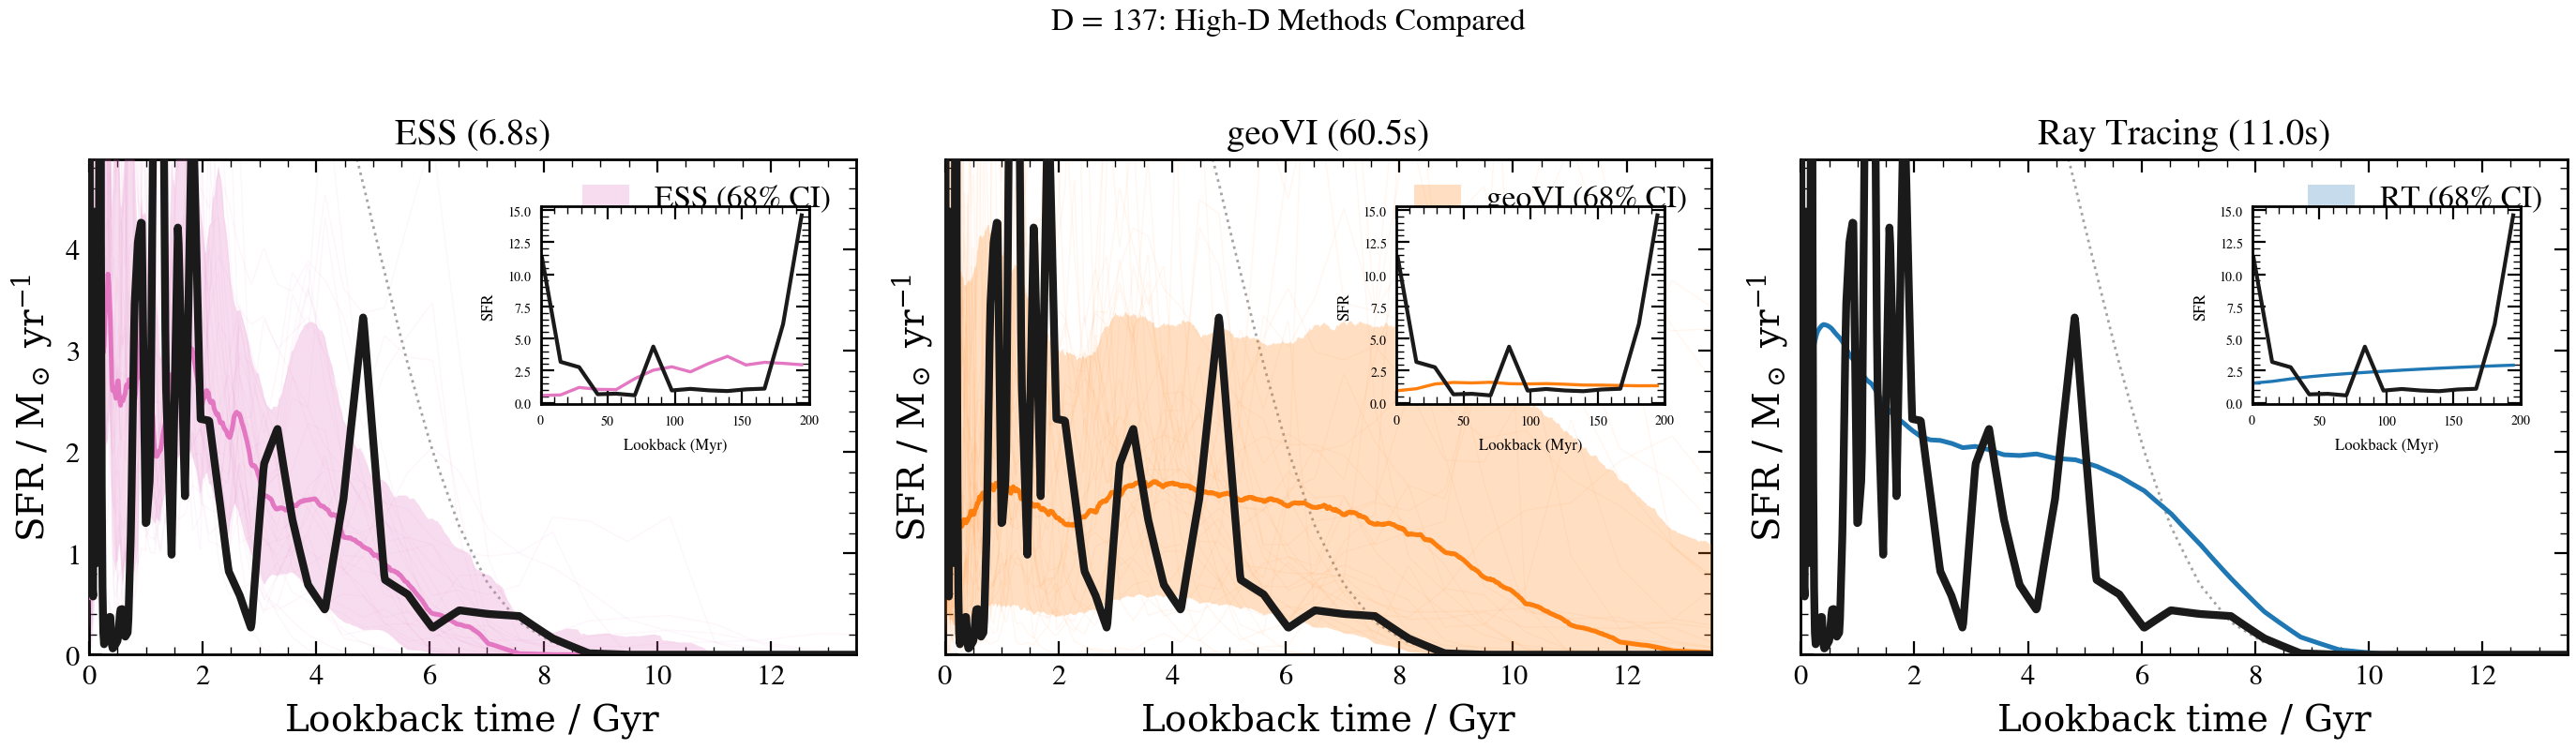

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

plot_sfh(
    model_stoch,
    result_ess_s,
    true_params=true_stoch,
    ax=ax1,
    color=COLORS["ess"],
    label="ESS",
    method="ESS",
    show_mean_sfh=True,
)
ax1.set_title(f"ESS ({timings_s['ESS']:.1f}s)")

plot_sfh(
    model_stoch,
    result_geovi_s,
    true_params=true_stoch,
    ax=ax2,
    color=COLORS["geovi"],
    label="geoVI",
    method="geoVI",
    show_mean_sfh=True,
)
ax2.set_title(f"geoVI ({timings_s['geoVI']:.1f}s)")

plot_sfh(
    model_stoch,
    result_rt_s,
    true_params=true_stoch,
    ax=ax3,
    color=COLORS["rt"],
    label="RT",
    method="RT",
    show_mean_sfh=True,
)
ax3.set_title(f"Ray Tracing ({timings_s['RT']:.1f}s)")

fig.suptitle("D = 137: High-D Methods Compared", fontsize=12, y=1.02)
fig.tight_layout()
plt.savefig("fig04_sfh_high_d.png", dpi=150, bbox_inches="tight")
plt.show()

### Corner: Physical params at D=137

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

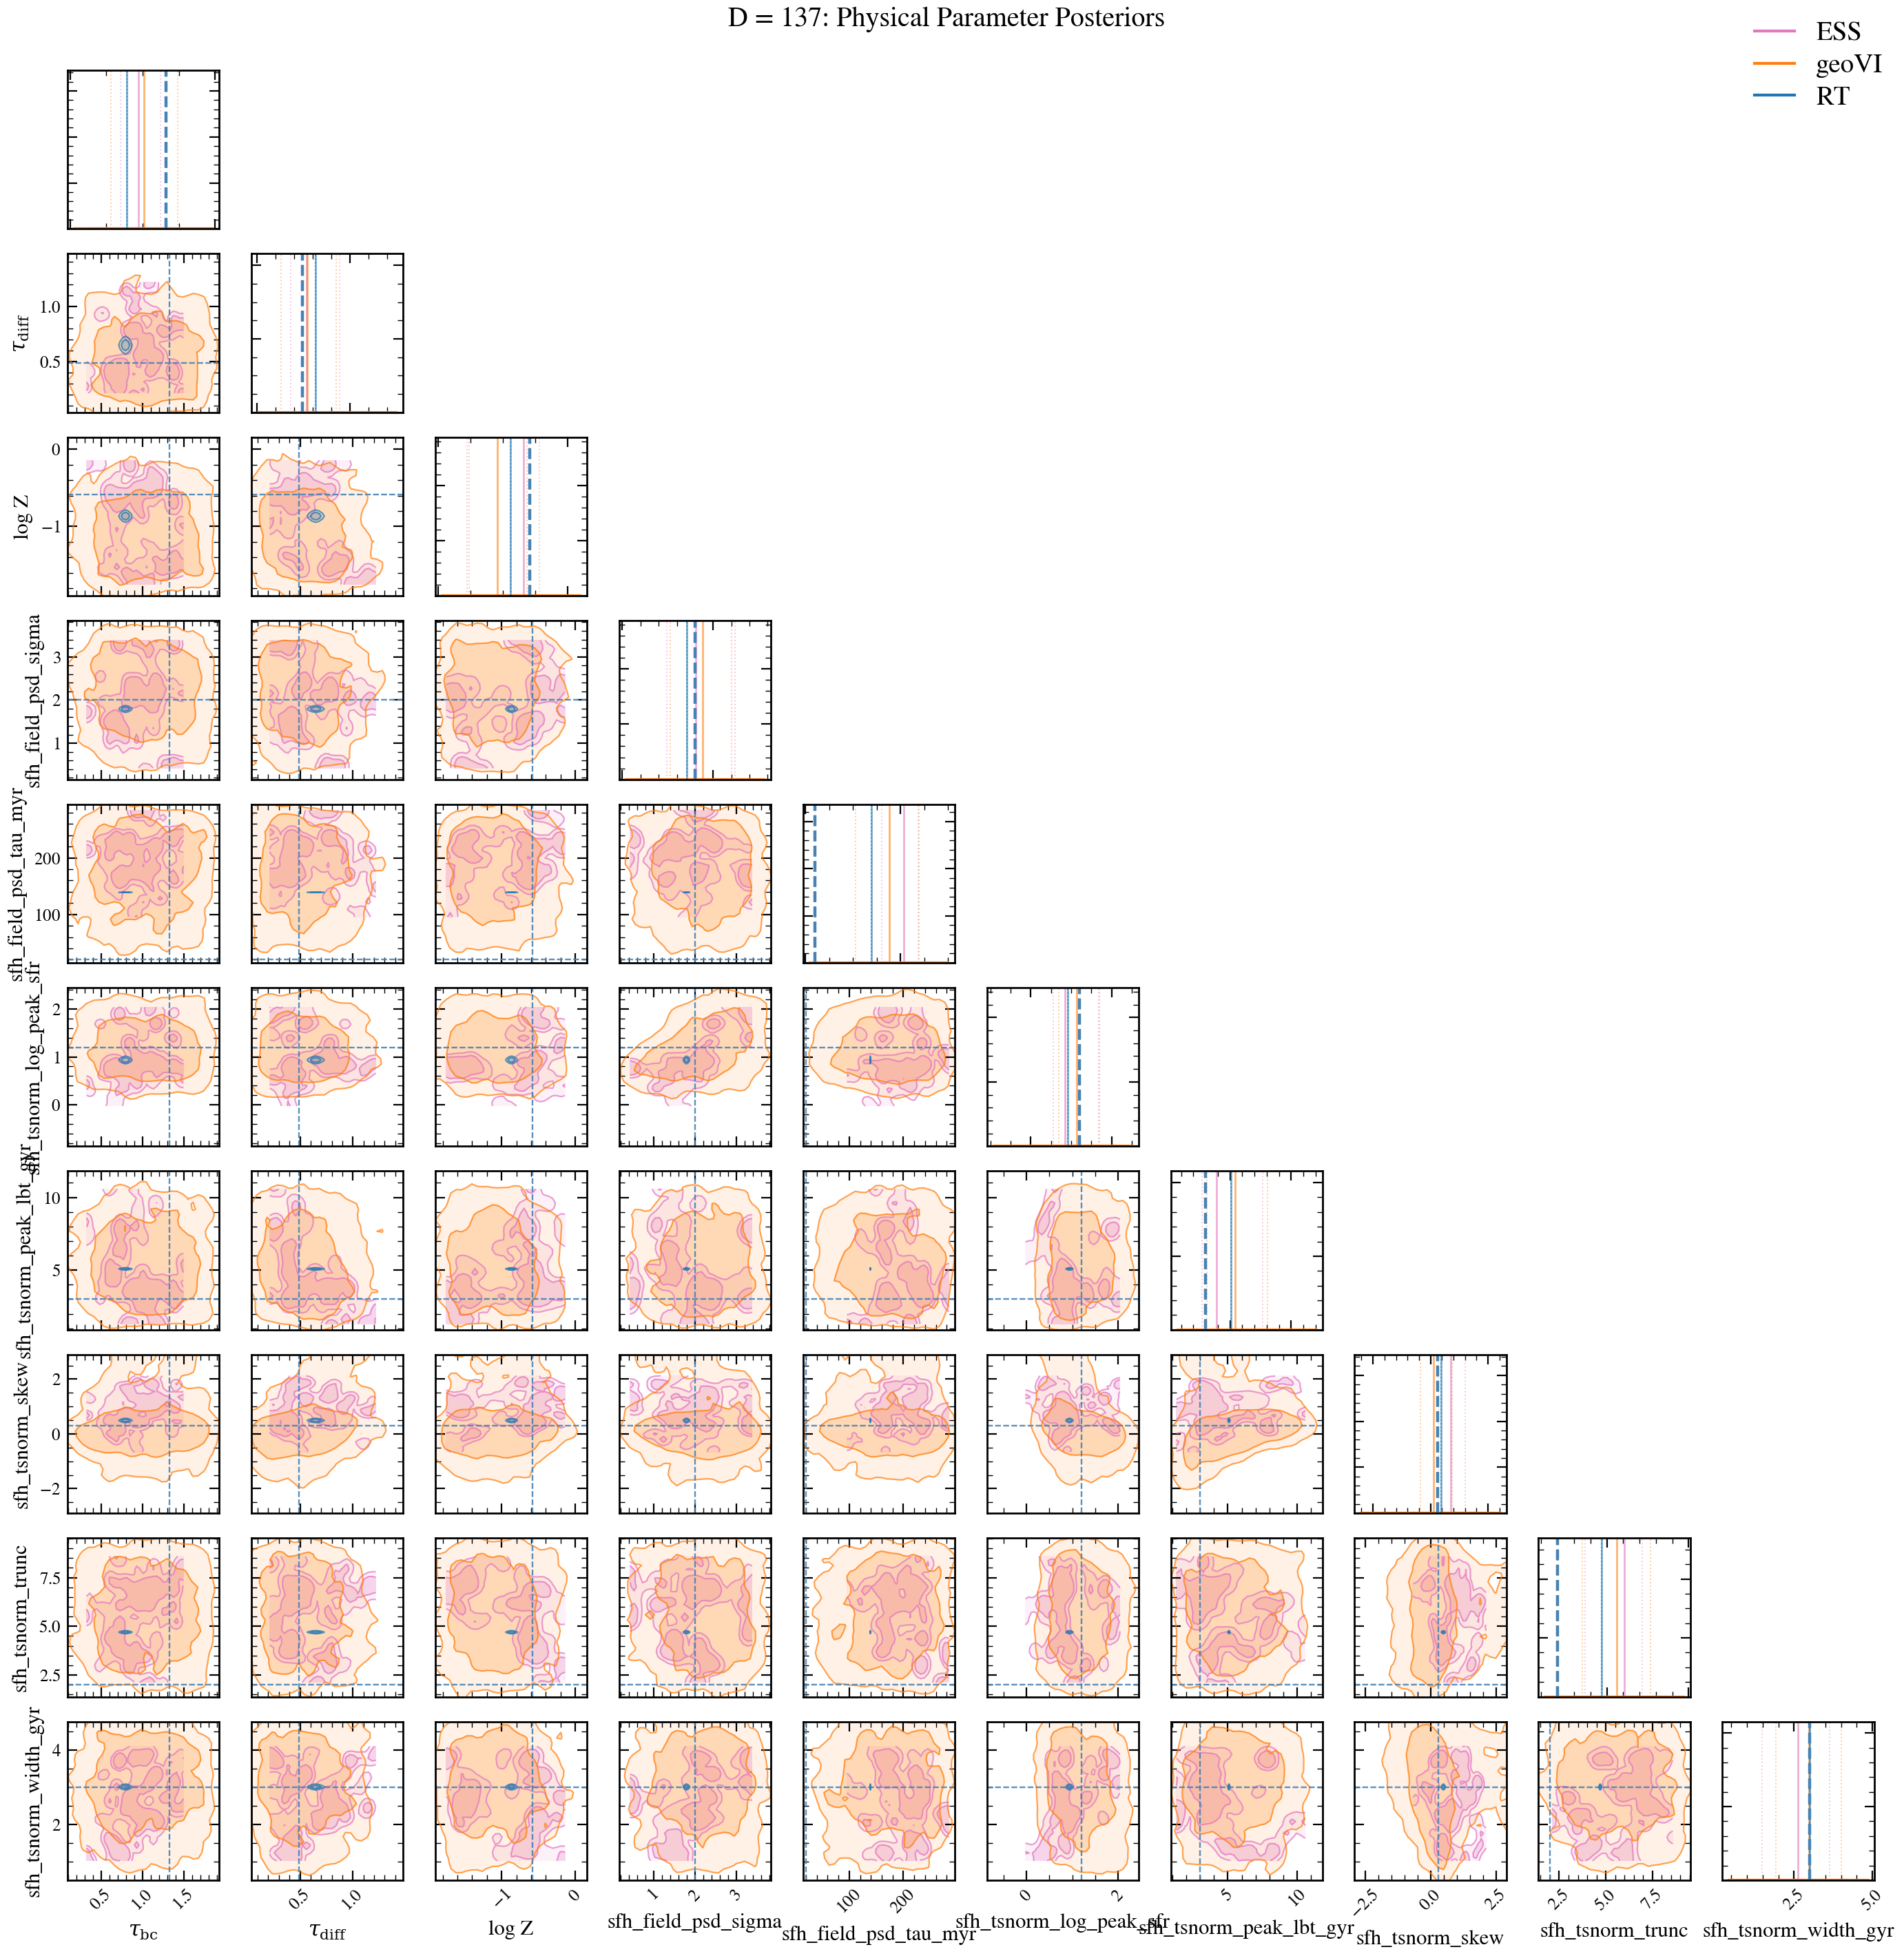

In [23]:
stoch_phys = [p for p in spec_stoch.free_params if "xi" not in p]
fig = plot_corner_comparison(
    [result_ess_s, result_geovi_s, result_rt_s],
    labels=["ESS", "geoVI", "RT"],
    colors=[COLORS["ess"], COLORS["geovi"], COLORS["rt"]],
    truths=true_stoch,
    params=stoch_phys,
)
if fig is not None:
    fig.suptitle("D = 137: Physical Parameter Posteriors", y=1.02)
    plt.savefig("fig06_corner_high_d.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Decision Tree

| Scenario | Recommended | Why |
|----------|------------|-----|
| Default for everything | `native_geovi` | Fast, JIT-compiled, any D |
| Exact posterior (D < 20) | `nuts` | Gold standard |
| Exact posterior (D > 50) | `raytrace` | Scales to high D |
| Quick error bars from MAP | `laplace` | Instant, Gaussian |
| Fast approximate posterior | `pathfinder` | 10x faster than NUTS |
| Gaussian-prior latent models | `elliptical_slice` | Natural for GP priors |
| Initialize NUTS/RT chains | `pathfinder` or `map` | Good starting points |
| Bayesian evidence | `nss` or `laplace` | Nested sampling or Laplace estimate |
| Hierarchical inference | `native_geovi` | Block Gibbs for shared PSD |